In [ ]:
!pip install segment-anything

In [ ]:
# Baixar o checkpoint do modelo ViT-B SAM Model para a sessão do Colab
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-02-28 14:20:20--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.202.30, 13.35.202.67, 13.35.202.17, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.202.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  87.9MB/s    in 4.2s    

2025-02-28 14:20:24 (85.3 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
!pwd

/content


/usr/local/lib/python3.11/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


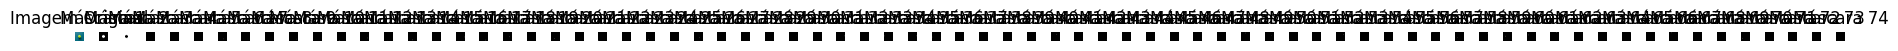

In [ ]:
# Importando as bibliotecas necessárias
import torch
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import matplotlib.pyplot as plt
import requests
import numpy as np
from PIL import Image
from io import BytesIO
import cv2

# URL da imagem que queremos segmentar
url1='https://img.freepik.com/free-photo/top-view-one-tennis-ball_23-2148796915.jpg?t=st=1731622061~exp=1731625661~hmac=9ef108375384e24b2bee653b72477a60b743c6e2c26e3b371d972bb9d8ad25f0&w=740'

url2 = 'https://img.freepik.com/premium-photo/closeup-beautiful-orange-tree-with-orange-large-round-oranges-surrounded-by-many-bright-green-leaves_116124-4580.jpg?w=740'

url3='https://img.freepik.com/free-photo/sincere-friend-maltipu-little-dog-is-posing_155003-22635.jpg?t=st=1731630012~exp=1731633612~hmac=824c3c32b95deadf74ad9da46836d590a9c4e13d58d30b73b58be1a99609ba90&w=740'

# Função para baixar a imagem
response = requests.get(url1)
image = Image.open(BytesIO(response.content))
image = np.array(image)

# Baixar o modelo SAM pré-treinado
sam_checkpoint = "/content/sam_vit_b_01ec64.pth"  # Você pode usar o link direto para o modelo SAM pré-treinado

# Definir o caminho para o checkpoint do modelo
model_type = "vit_b"  # O tipo de modelo, "vit_b" é uma versão mais leve
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)

# Colocar o modelo em modo de avaliação
sam.eval()

# Gerar a máscara para a imagem
mask_generator = SamAutomaticMaskGenerator(sam)

# Reduzindo a imagem para 1/2 do tamanho original para melhorar o desempenho
image_resized = cv2.resize(image, (image.shape[1] // 2, image.shape[0] // 2))

# Ajustando parâmetros do gerador de máscara para gerar menos máscaras
mask_generator.box_threshold = 0.5  # Aumente se muitas máscaras indesejadas
mask_generator.mask_threshold = 0.7  # Aumente para aumentar a confiança da máscara
mask_generator.stability_score_threshold = 0.9  # Aumente para evitar máscaras fracas

masks = mask_generator.generate(image_resized)

# Exibir as máscaras geradas
fig, ax = plt.subplots(1, len(masks) + 1, figsize=(18, 6))

# Exibir a imagem original
ax[0].imshow(image_resized)
ax[0].set_title('Imagem Original')
ax[0].axis('off')

# Exibir as máscaras geradas
for i, mask in enumerate(masks):
    ax[i+1].imshow(mask['segmentation'], cmap='gray')
    ax[i+1].set_title(f'Máscara {i+1}')
    ax[i+1].axis('off')

plt.tight_layout()
plt.show()


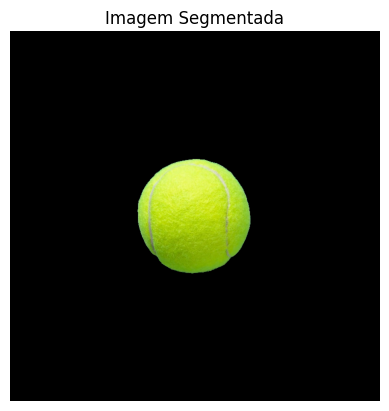

In [ ]:
# Escolher a segunda máscara gerada (ou qualquer outra, dependendo da segmentação)
mask = masks[1]['segmentation']

# Criar uma imagem segmentada utilizando a máscara
# A máscara tem valores binários (True/False), onde True representa a área segmentada
segmented_image = np.copy(image_resized)
segmented_image[~mask] = 0  # Zera os pixels do fundo (onde a máscara é False)

# Exibir a imagem segmentada
plt.imshow(segmented_image)
plt.title('Imagem Segmentada')
plt.axis('off')
plt.show()